<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_01_dataset_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importer les bibliothèques

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# import SVM
from sklearn.svm import SVC
# import KNN
from sklearn.neighbors import KNeighborsClassifier
# import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
# import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Vue d'ensemble à ce qui contient le dataset

In [77]:
df = sns.load_dataset('titanic')

In [78]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


#  Objectif du Projet : Analyse et Prétraitement du Dataset Titanic

Comprendre les facteurs qui ont influencé la survie des passagers du Titanic en nettoyant, explorant et préparant les données pour un futur modèle de Machine Learning.

---

##  Checklist d'Analyse (La Méthode)

### 1. Analyse de Forme
* **Variable Cible (Target) :** `survived` (Variable binaire : 0 = Décédé, 1 = Survivant).
* **Nombre de Lignes et Colonnes :** (891, 15)
* **Types de Variables :** Identification des types numériques (`int`, `float`) et catégoriels (`object`, `bool`).
* **Analyse des Valeurs Manquantes (NaN) :** `age` (20.4%), `embarked` / `embark_town` (2 valeurs), et `deck` (79.2%).
* **Nettoyage des Doublons sur les lignes :** 784 lignes uniques, 107 lignes dupliquées à éliminer.
* **Nettoyage des Doublons de colonnes :** Éliminer les colonnes redondantes pour éviter le Data Leakage (`alive`, `class`, `embark_town`).

### 2. Analyse de Fond (Exploration)
* **Visualisation de la Target :** Analyse du déséquilibre des classes (61% de décès vs 39% de survie).
* **Analyses Bivariées (Relation Features / Target) :**
    * *Hypothèse 1 :* Les femmes et les enfants ont eu un taux de survie plus élevé (`sex`, `age` vs `survived`).
    * *Hypothèse 2 :* La classe sociale et le prix du billet ont joué un rôle majeur (`pclass`, `fare` vs `survived`).
* **Analyses Multivariées :** Vérification des corrélations numériques via la Heatmap (lien fort à -0.55 entre `fare` et `pclass`).

---

##  3. Prétraitement des Données (Data Preprocessing)

###  Nettoyage et Suppression des Redondances
* **Suppression des colonnes doublons :** Retirer `alive`, `class`, et `embark_town` (100% redondantes).
* **Suppression de la colonne inexploitable :** Retirer `deck` (trop de valeurs manquantes : 79.2%).
* **Suppression des doublons de lignes :** Supprimer les 107 lignes identiques pour ne pas fausser l'apprentissage.

###  Traitement des Valeurs Manquantes (NaN)
* **Imputation intelligente de l'Âge (20.4% de NaN) :** Remplacer les trous par la médiane de l'âge calculée *par Sexe et par Classe* pour rester précis.
* **Nettoyage des lignes isolées :** Supprimer les 2 lignes vides de la colonne `embarked`.

###  Feature Engineering (Création de variables)
* **Création de `taille_famille` :** Fusionner les colonnes corrélées via la formule : `taille_famille = sibsp + parch + 1`.
* **Création de `est_seul` :** Variable booléenne (0 ou 1) pour identifier les passagers sans aucun proche.

###  Encodage des Variables Catégorielles (Texte ──► Chiffres)
* Les algorithmes ne comprennent pas le texte, il faut transformer :
    * **`sex` :** Encodage binaire (0 = male, 1 = female).
    * **`embarked` :** One-Hot Encoding (création de colonnes séparées pour les ports C, Q, S).

###  Mise à l'Échelle (Scaling)
* **Standardisation :** Mettre à l'échelle `age` et `fare` pour éviter que les grands écarts de prix n'écrasent les autres données numériques lors des calculs mathématiques du modèle.

---

##  4. Division des Données (Train / Test Split)

* **Séparation Features / Target :** Isoler le dataset entre la matrice des variables prédictives $X$ et le vecteur cible $y$ (`survived`).
* **Découpage des Données :** Diviser l'ensemble en un groupe d'**Entraînement (Train - 80%)** pour fabriquer l'IA et un groupe de **Test (20%)** pour évaluer ses performances finales à l'aveugle.

# **1. Analyse de Forme**

###

### *   **La cible**



<Axes: ylabel='count'>

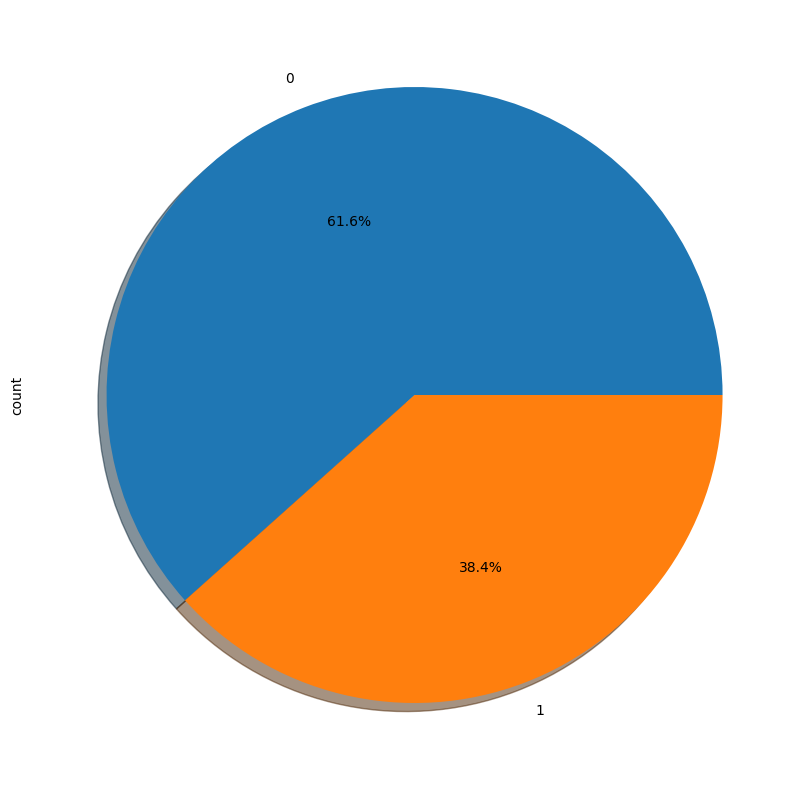

In [81]:
df['survived'].value_counts().plot.pie(figsize=(10,10), autopct='%1.1f%%', shadow=True)

## * **Size dataset**

In [82]:
df.shape

(891, 15)

## * T**ypes de variables**

In [83]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


<Axes: ylabel='count'>

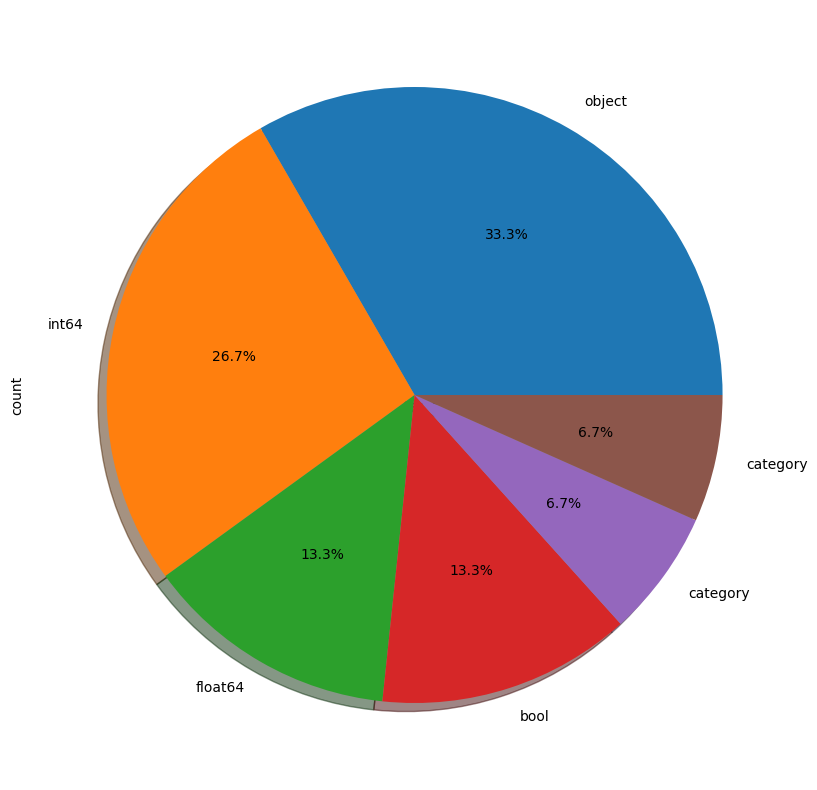

In [84]:
df.dtypes.value_counts().plot.pie(figsize=(10,10), autopct='%1.1f%%', shadow=True)

## * **Analyse de valeurs manquantes**

In [85]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


<Axes: >

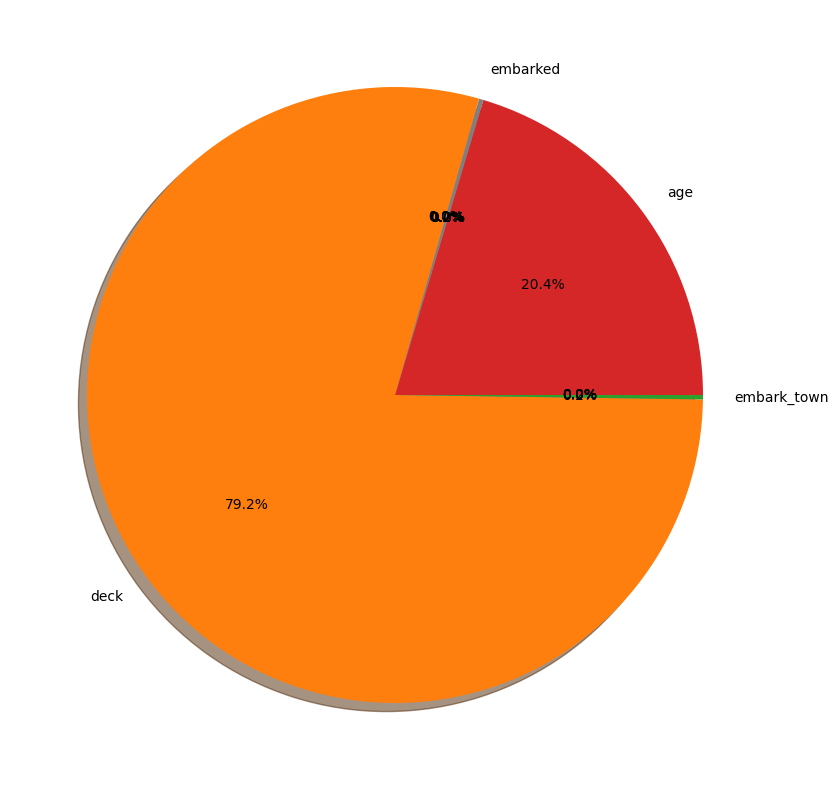

In [86]:
df.isna().sum().plot.pie(figsize=(10,10), autopct='%1.1f%%', shadow=True)

## * **Nettoyage des Doublons sur les lignes**

In [87]:
print(f"{df.duplicated().value_counts()}")

False    784
True     107
Name: count, dtype: int64


<Axes: ylabel='count'>

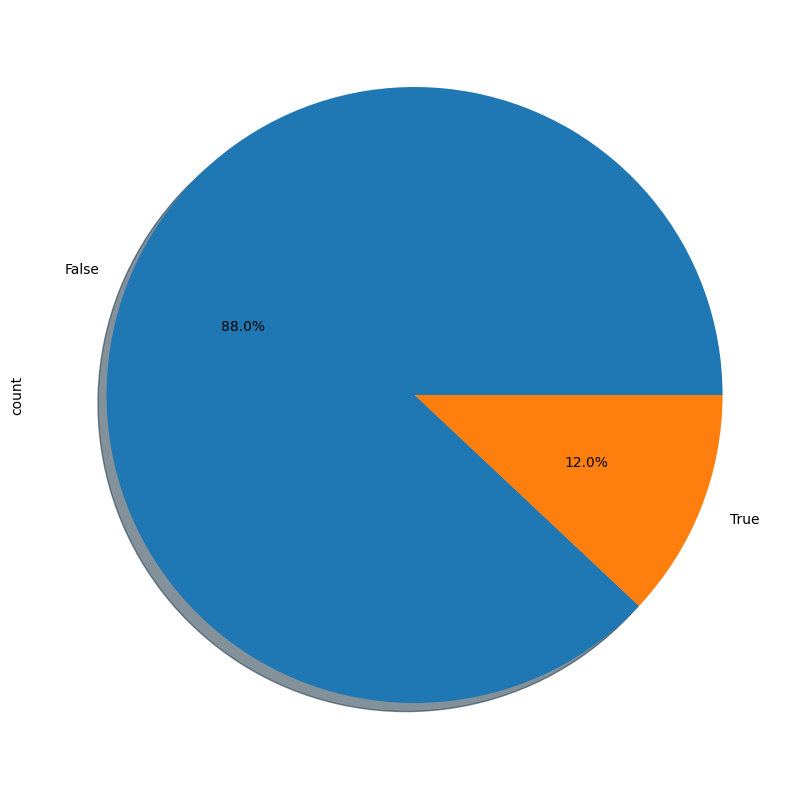

In [88]:
df.duplicated().value_counts().plot.pie(figsize=(10,10), autopct='%1.1f%%', shadow=True)

## * **Nettoyage des Doublons sur les col**
Éliminer les colonnes redondantes pour éviter le Data Leakage, c'est quoi data Leakage ? Signifie que 2 col differentes apportent même informations mais écritent differement donc garder les deux algo IA va tricher.

*  Pour les variables Catégorielles (Texte)

In [91]:
# On crée une copie temporaire du dataset où TOUT est transformé en numéros
df_num_temporaire = df.apply(lambda col: col.astype('category').cat.codes)

# On lance ta fameuse double boucle sur TOUTES les colonnes
colonnes = df_num_temporaire.columns
for i in range(len(colonnes)):
    for j in range(i + 1, len(colonnes)):
        col1 = colonnes[i]
        col2 = colonnes[j]

        # Calcul de similitude sur le dataset converti
        similitude = (df_num_temporaire[col1] == df_num_temporaire[col2]).mean()

        if similitude > 0.95:
            print(f"⚠️ Alerte Doublon Universel : '{col1}' et '{col2}' sont identiques à {similitude*100:.2f}%")

⚠️ Alerte Doublon Universel : 'survived' et 'alive' sont identiques à 100.00%
⚠️ Alerte Doublon Universel : 'pclass' et 'class' sont identiques à 100.00%
⚠️ Alerte Doublon Universel : 'embarked' et 'embark_town' sont identiques à 100.00%


**Conclusion:** Nous allons supprimer l'une de ses variables

*  Pour les variables numériques

In [93]:
df.select_dtypes(include=['int64', 'float64']).corr().abs()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,0.332658,0.086548,0.036589,0.070307,0.246769
pclass,0.332658,1.000000,0.369361,0.088014,0.040296,0.549216
age,0.086548,0.369361,1.000000,0.315116,0.195036,0.092707
sibsp,0.036589,0.088014,0.315116,1.000000,0.381433,0.135147
parch,0.070307,0.040296,0.195036,0.381433,1.000000,0.191942
fare,0.246769,0.549216,0.092707,0.135147,0.191942,1.000000


In [94]:
# Calculer la matrice de corrélation (en valeur absolue)
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr().abs()

# Trouver les colonnes avec une corrélation supérieure à 0.90
colonnes_a_supprimer = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.9: #  seuil de tolérance
            colname = corr_matrix.columns[i]
            colonnes_a_supprimer.add(colname)

print("Colonnes numériques fortement redondantes à supprimer :", colonnes_a_supprimer)

Colonnes numériques fortement redondantes à supprimer : set()


rien à supprimer ici pour cette hypothèse

# **2. Analyse de Fond (Exploration)**

## * Visualisation de la Target :
 Quelle est la proportion de survivants ? (Vérifier le déséquilibre des classes)

<Axes: ylabel='count'>

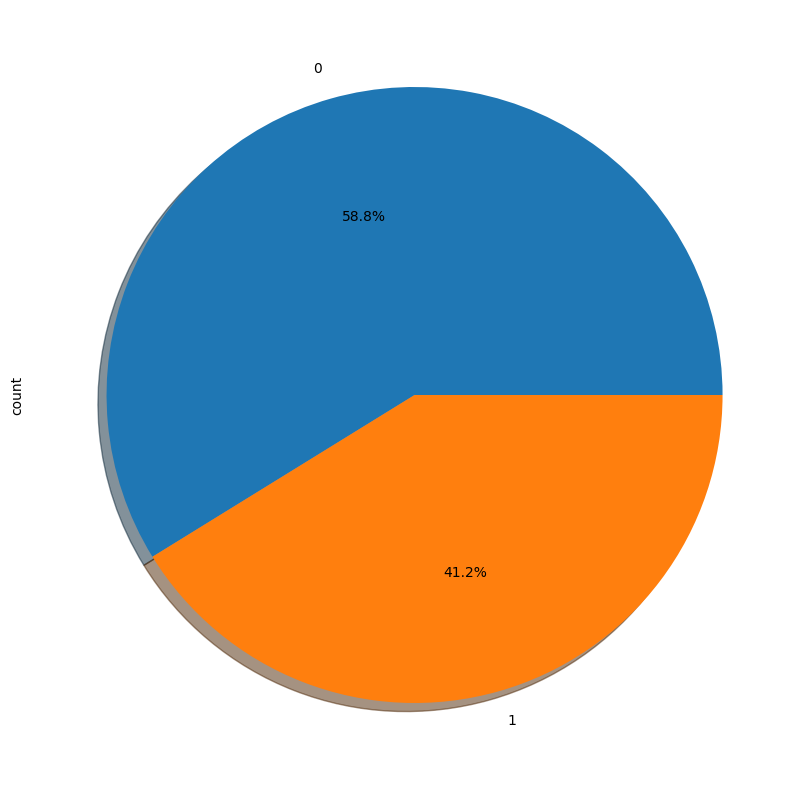

In [95]:
df['survived'].value_counts().plot.pie(figsize=(10,10), autopct='%1.1f%%', shadow=True)

Il y a moins de désequilibrage donc rien à faire.

## * **Analyses Bivariées (Relation Features / Target)** :

In [96]:
cols_analyses = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(cols_analyses)

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


### Age vs Target

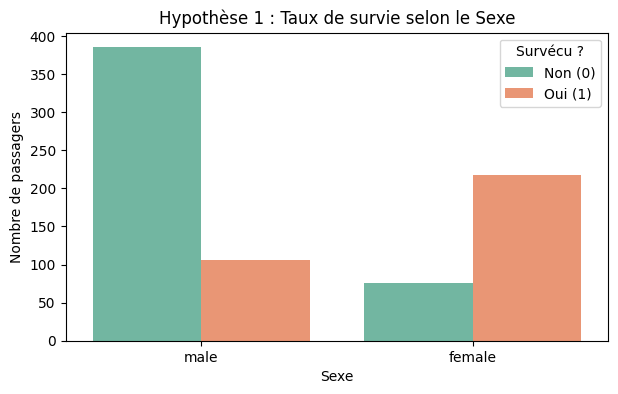

In [97]:
plt.figure(figsize=(7, 4))
# countplot est parfait pour le texte (sex) vs la cible (survived)
sns.countplot(x='sex', hue='survived', data=df, palette='Set2')
plt.title("Hypothèse 1 : Taux de survie selon le Sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de passagers")
plt.legend(title="Survécu ?", labels=["Non (0)", "Oui (1)"])
plt.show()

In [98]:
# pourcentage des  homes et femmes survecus
df.groupby('sex')['survived'].value_counts(normalize=True)*100

sex     survived
female  1           74.061433
        0           25.938567
male    0           78.411405
        1           21.588595
Name: proportion, dtype: float64

* Homme 21.6% survecus et environ 78.4% morts.
* Femme environ 74.1% survecues   et environ 26% mortes.
**Conclusion:** : Les femmes ont la chance de survecu plus les hommes


/tmp/ipykernel_9623/2730971573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df, palette='Pastel1')


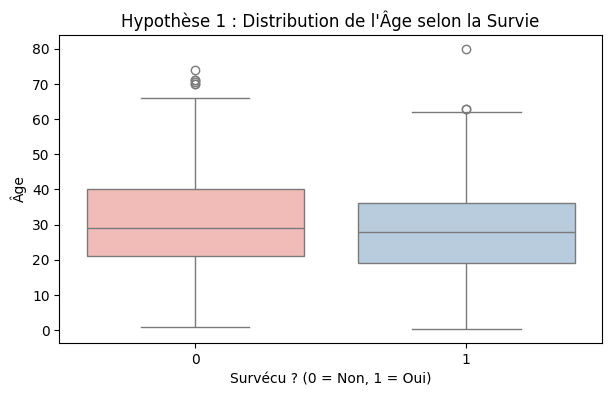

In [99]:
plt.figure(figsize=(7, 4))
# boxplot est parfait pour un chiffre (age) vs la cible (survived)
sns.boxplot(x='survived', y='age', data=df, palette='Pastel1')
plt.title("Hypothèse 1 : Distribution de l'Âge selon la Survie")
plt.xlabel("Survécu ? (0 = Non, 1 = Oui)")
plt.ylabel("Âge")
plt.show()

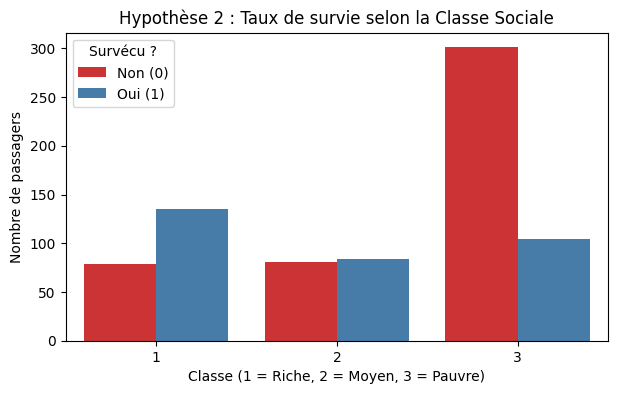

In [100]:
plt.figure(figsize=(7, 4))
sns.countplot(x='pclass', hue='survived', data=df, palette='Set1')
plt.title("Hypothèse 2 : Taux de survie selon la Classe Sociale")
plt.xlabel("Classe (1 = Riche, 2 = Moyen, 3 = Pauvre)")
plt.ylabel("Nombre de passagers")
plt.legend(title="Survécu ?", labels=["Non (0)", "Oui (1)"])
plt.show()

On voit que les moyens riches et riches ont la chance d'être survecu plus que les pauvres

/tmp/ipykernel_9623/2680128873.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['survived'] == 0]['fare'], label='Décédés (0)', shade=True, color='red')
/tmp/ipykernel_9623/2680128873.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['survived'] == 1]['fare'], label='Survivants (1)', shade=True, color='green')


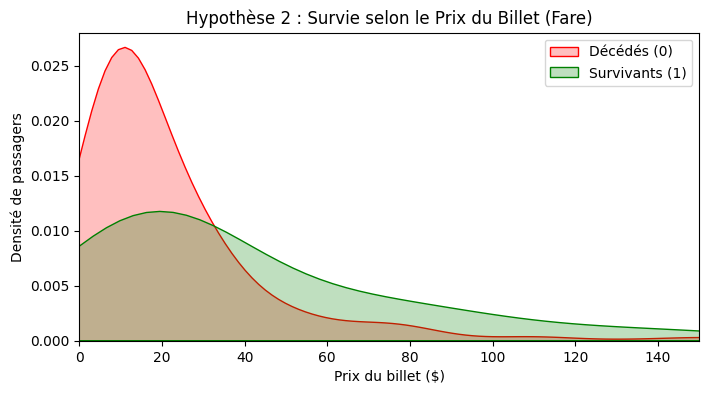

In [101]:
plt.figure(figsize=(8, 4))
# kdeplot montre la "vague" de répartition des prix
sns.kdeplot(df[df['survived'] == 0]['fare'], label='Décédés (0)', shade=True, color='red')
sns.kdeplot(df[df['survived'] == 1]['fare'], label='Survivants (1)', shade=True, color='green')
plt.title("Hypothèse 2 : Survie selon le Prix du Billet (Fare)")
plt.xlabel("Prix du billet ($)")
plt.ylabel("Densité de passagers")
plt.xlim(0, 150) # On limite à 150$ pour mieux voir, car certains billets étaient ultra chers
plt.legend()
plt.show()

**Conclusion :** Plus le billet était cher, plus on avait de chances de s'en sortir.

## * **Analyses Multivariées :**  
Vérifier les corrélations entre les variables (ex: lien entre fare et pclass).

In [102]:
print(f"La valeur de correlation entre fare et pcla:{df['fare'].corr(df['pclass'])}")

La valeur de correlation entre fare et pcla:-0.5492162083667461


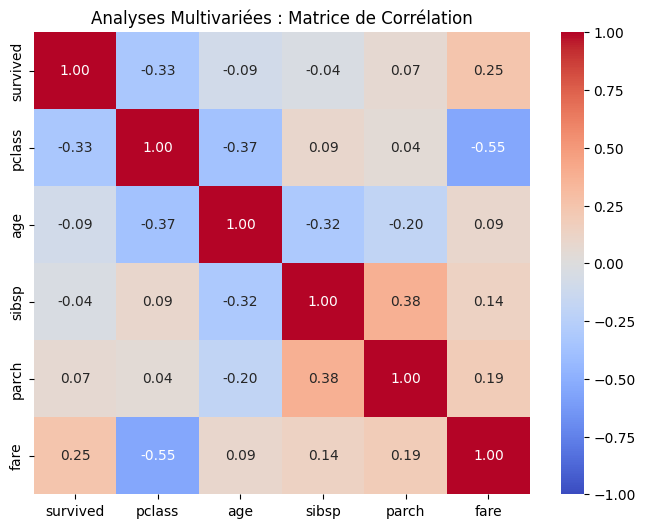

In [103]:
df_numeric = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]

matrix_corr = df_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Analyses Multivariées : Matrice de Corrélation")
plt.show()

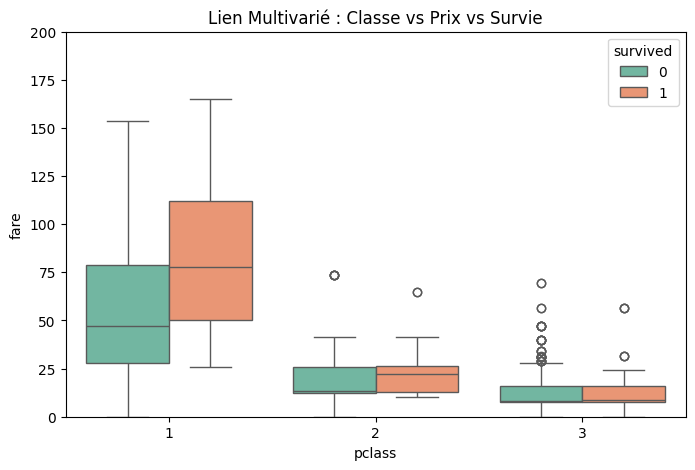

In [104]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='pclass', y='fare', hue='survived', data=df, palette='Set2')
plt.title("Lien Multivarié : Classe vs Prix vs Survie")
plt.ylim(0, 200)
plt.show()

# **3. Prétraitement des Données (Data Preprocessing)**

## * **Nettoyage et Suppression des Redondances**

In [105]:
df = df.drop(columns=['embark_town','alive','class'],axis=1)

In [106]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,NaN,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,NaN,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,NaN,True


### * **Suppression de la colonne inexploitable**

In [110]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,106
sibsp,0
parch,0
fare,0
embarked,2
who,0
adult_male,0


In [108]:
df.isna().sum().value_counts(normalize=True)*100

,proportion
0,75.000000
106,8.333333
2,8.333333
582,8.333333


deck a 75% de valeurs manquantes donc supprimer cette colonne sera mieux.

In [111]:
df = df.drop(columns=['deck'],axis=1)

In [112]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,True


###  * **Suppression des doublons de lignes**

In [ ]:
df = df.drop_duplicates()

In [114]:
df.shape

(784, 11)

## * **Traitement des Valeurs Manquantes (NaN)**

### Imputation intelligente de l'Âge (20.4% de NaN)

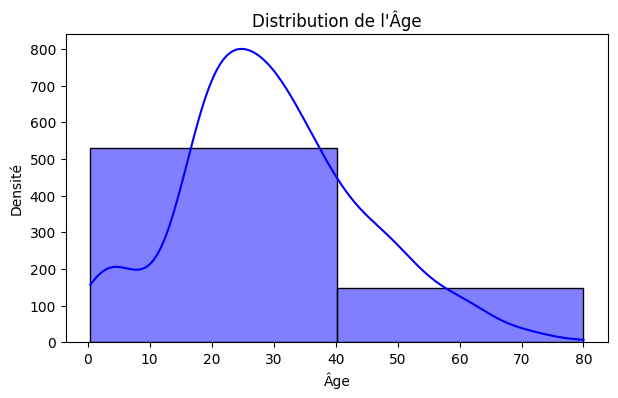

In [118]:
# distribution de l'age
plt.figure(figsize=(7, 4))
sns.histplot(df['age'], kde=True, bins=2, color='blue')
plt.title("Distribution de l'Âge")
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.show()

In [119]:
 # Remplacer les trous par la médiane de l'âge calculée par Sexe et par Classe pour rester précis.
df['age'] = df.groupby(['sex', 'pclass'])['age'].transform(lambda x: x.fillna(x.median()))

In [122]:
df['age'].isna().sum()

np.int64(0)

### Nettoyage des lignes isolées : Supprimer les 2 lignes vides de la colonne embarked.

In [123]:
df = df.drop(df[df['embarked'].isna()].index, axis=0, inplace=False)

In [125]:
df['embarked'].isna().sum()

np.int64(0)

## * **Feature Engineering (Création de variables)**

In [126]:
# la taille de la famille
df['taille_famille'] = df['sibsp'] + df['parch'] + 1

# seul so le nombre de ta famille est toi même
df['est_seul'] = 0

# remplir la colonne mtn
df.loc[df['taille_famille'] == 1, 'est_seul'] = 1


In [127]:
print(df[['sibsp', 'parch', 'taille_famille', 'est_seul']].head(10))

   sibsp  parch  taille_famille  est_seul
0      1      0               2         0
1      1      0               2         0
2      0      0               1         1
3      1      0               2         0
4      0      0               1         1
5      0      0               1         1
6      0      0               1         1
7      3      1               5         0
8      0      2               3         0
9      1      0               2         0


/tmp/ipykernel_9623/2225076893.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='est_seul', y='survived', data=df, palette='Blues')


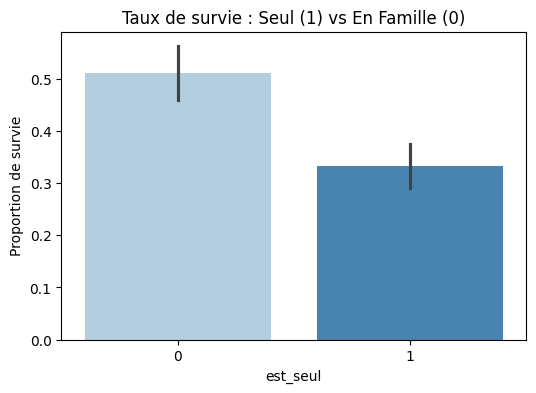

In [128]:
plt.figure(figsize=(6, 4))
sns.barplot(x='est_seul', y='survived', data=df, palette='Blues')
plt.title("Taux de survie : Seul (1) vs En Famille (0)")
plt.ylabel("Proportion de survie")
plt.show()

Les gens qui ont été avec leur famille avaient plus de chance de survie que seul ce qui explique toujours la richesse.

In [129]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone,taille_famille,est_seul
0,0,3,male,22.0,1,0,7.2500,S,man,True,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,man,True,True,1,1


## * **Encodage des Variables Catégorielles**

In [131]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

In [132]:
# One-Hot Encoding pour 'embarked' et 'who'
df_encoded = pd.get_dummies(df, columns=['embarked', 'who'], drop_first=True, dtype=int)

In [133]:
# On supprime les variables redondantes (sibsp, parch et alone)
df_final = df_encoded.drop(columns=['sibsp', 'parch', 'alone'])

In [136]:
df_final.head()

,survived,pclass,sex,age,fare,adult_male,taille_famille,est_seul,embarked_Q,embarked_S,who_man,who_woman
0,0,3,0,22.0,7.2500,1,2,0,0,1,1,0
1,1,1,1,38.0,71.2833,0,2,0,0,0,0,1
2,1,3,1,26.0,7.9250,0,1,1,0,1,0,1
3,1,1,1,35.0,53.1000,0,2,0,0,1,0,1
4,0,3,0,35.0,8.0500,1,1,1,0,1,1,0


## * **Mise à l'Échelle (Scaling)**

In [137]:
# Extraction et Standardisation des colonnes cibles : 'age' et 'fare'
scaler = StandardScaler()

# On ajuste le scaler et on transforme les données
df_final[['age', 'fare']] = scaler.fit_transform(df_final[['age', 'fare']])

In [138]:
df_final.head()

,survived,pclass,sex,age,fare,adult_male,taille_famille,est_seul,embarked_Q,embarked_S,who_man,who_woman
0,0,3,0,-0.545874,-0.524440,1,2,0,0,1,1,0
1,1,1,1,0.604453,0.703591,0,2,0,0,0,0,1
2,1,3,1,-0.258292,-0.511495,0,1,1,0,1,0,1
3,1,1,1,0.388767,0.354871,0,2,0,0,1,0,1
4,0,3,0,0.388767,-0.509097,1,1,1,0,1,1,0


# **4. Division des Données (Train / Test Split)**

In [140]:
y = df_final['survived']
X = df_final.drop(columns=['survived'])

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [142]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((625, 11), (157, 11), (625,), (157,))

# **5. Modèles**

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluer_modeles(dictionnaire_modeles, X_train, X_test, y_train, y_test):
    """
    Fonction automatique pour entraîner, évaluer et comparer plusieurs modèles.
    Affiche les scores d'entraînement/test et les matrices de confusion.
    """
    # Liste pour stocker les résultats et faire un tableau comparatif à la fin
    resultats = []

    # Configuration de la taille de la figure pour les graphiques
    num_modeles = len(dictionnaire_modeles)
    fig, axes = plt.subplots(1, num_modeles, figsize=(5 * num_modeles, 4), squeeze=False)

    for idx, (nom_modele, modele) in enumerate(dictionnaire_modeles.items()):
        # 1. Entraînement du modèle
        modele.fit(X_train, y_train)

        # 2. Prédictions
        y_pred_train = modele.predict(X_train)
        y_pred_test = modele.predict(X_test)

        # 3. Calcul des scores (Accuracy)
        score_train = accuracy_score(y_train, y_pred_train)
        score_test = accuracy_score(y_test, y_pred_test)

        # Enregistrement des scores
        resultats.append({
            'Modèle': nom_modele,
            'Score Train (Apprentissage)': f"{score_train:.4f}",
            'Score Test (Validation)': f"{score_test:.4f}",
            'Overfitting (Écart)': f"{score_train - score_test:.4f}"
        })

        # 4. Matrice de confusion sur le TEST
        cm = confusion_matrix(y_test, y_pred_test)

        # Affichage graphique de la matrice
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx], cbar=False)
        axes[0, idx].set_title(f"Matrice : {nom_modele}\n(Test Score: {score_test:.2f})")
        axes[0, idx].set_xlabel("Prédictions")
        axes[0, idx].set_ylabel("Réalité")

    plt.tight_layout()
    plt.show()

    # Retourner un joli tableau DataFrame avec tous les scores résumés
    return pd.DataFrame(resultats)

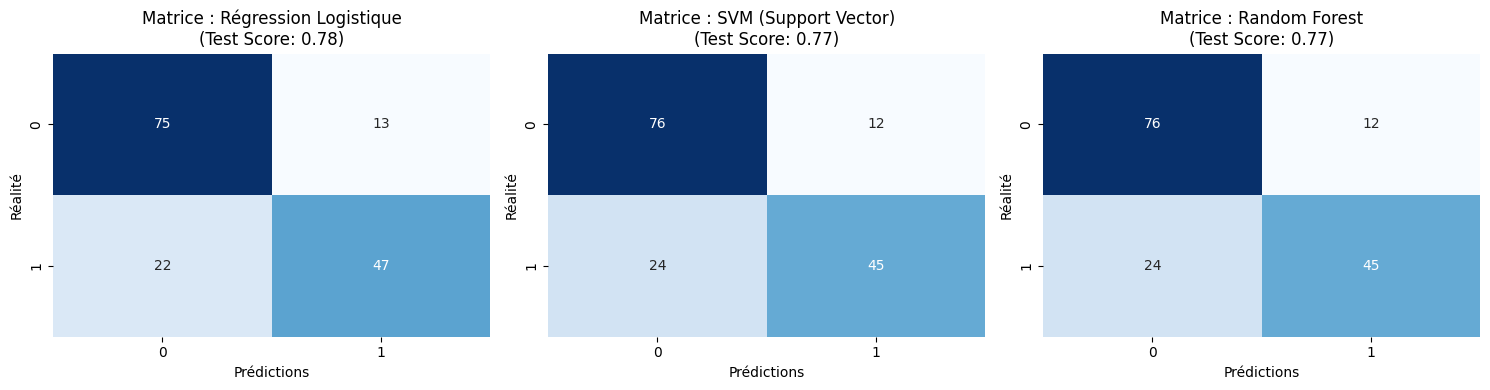

,Modèle,Score Train (Apprentissage),Score Test (Validation),Overfitting (Écart)
0,Régression Logistique,0.8144,0.7771,0.0373
1,SVM (Support Vector),0.8224,0.7707,0.0517
2,Random Forest,0.9824,0.7707,0.2117


In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier # Un petit bonus ultra-puissant

# 1. On prépare la liste des machines à tester
mes_modeles = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "SVM (Support Vector)": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. On lance la fonction magique
tableau_comparatif = evaluer_modeles(mes_modeles, X_train, X_test, y_train, y_test)

# 3. On affiche le tableau des scores
tableau_comparatif

In [165]:
import pandas as pd
import numpy as np

# 1. On retire np.random.seed() pour que ce soit VRAIMENT aléatoire à chaque clic !
indices_au_hasard = np.random.choice(X_test.index, size=10, replace=False)

# 2. Extraction des passagers correspondants
exemples_X = X_test.loc[indices_au_hasard]
exemples_y_reel = y_test.loc[indices_au_hasard]

# 3. Prédiction avec ton Random Forest (ou ml_rg si tu veux tester la Régression Logistique)
predictions = mes_modeles["Random Forest"].predict(exemples_X)

# 4. Dictionnaire de traduction pour le style
traduction = {0: "💀 Décédé", 1: "✨ Survivant"}

# 5. Construction du tableau comparatif
tableau_tests = pd.DataFrame({
    'ID Passager': indices_au_hasard,
    'Classe Réelle': [traduction[val] for val in exemples_y_reel],
    'Classe Prédite': [traduction[val] for val in predictions]
})

# 6. Colonne de vérification du succès
tableau_tests['Résultat'] = np.where(
    tableau_tests['Classe Réelle'] == tableau_tests['Classe Prédite'],
    "✅ Correct",
    "❌ Erreur"
)

# 7. Affichage sous forme de joli tableau Pandas (sans le print)
tableau_tests.reset_index(drop=True)

,ID Passager,Classe Réelle,Classe Prédite,Résultat
0,91,💀 Décédé,💀 Décédé,✅ Correct
1,2,✨ Survivant,✨ Survivant,✅ Correct
2,164,💀 Décédé,💀 Décédé,✅ Correct
3,797,✨ Survivant,💀 Décédé,❌ Erreur
4,579,✨ Survivant,✨ Survivant,✅ Correct
5,688,💀 Décédé,💀 Décédé,✅ Correct
6,398,💀 Décédé,💀 Décédé,✅ Correct
7,540,✨ Survivant,✨ Survivant,✅ Correct
8,445,✨ Survivant,✨ Survivant,✅ Correct
9,742,✨ Survivant,✨ Survivant,✅ Correct
